In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [2]:
from google.colab import files

uploaded = files.upload()

Saving xai_dataset.csv to xai_dataset.csv


In [3]:
df = pd.read_csv(
    "xai_dataset.csv"
)

In [4]:
print(df.shape)

df.head()

(7500, 28)


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,DEI,DEI_Category,attention_score,attention_category,addiction_level_num,NDI,dependency_category,attention_inverse,Aggression_Risk,Aggression_Category
0,21,1,3.23,2.01,0.89,4.55,7.55,248,154,3.95,...,13.434509,Low,96.024647,High,2,72.063834,High,3.975353,33.172813,Moderate
1,24,2,5.09,3.81,2.24,4.44,7.66,127,71,6.71,...,35.196089,Moderate,78.511173,High,2,39.144730,Moderate,21.488827,33.944637,Moderate
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,...,51.464091,Moderate,67.755773,Moderate,1,28.055204,Low,32.244227,39.379843,Moderate
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,...,52.636515,Moderate,63.214045,Moderate,2,59.108630,Moderate,36.785955,55.169185,Moderate
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,...,78.841602,High,41.917519,Moderate,3,78.615810,High,58.082481,81.798630,High


In [5]:
df.describe()



df.describe().to_csv(
    "descriptive_statistics.csv"
)

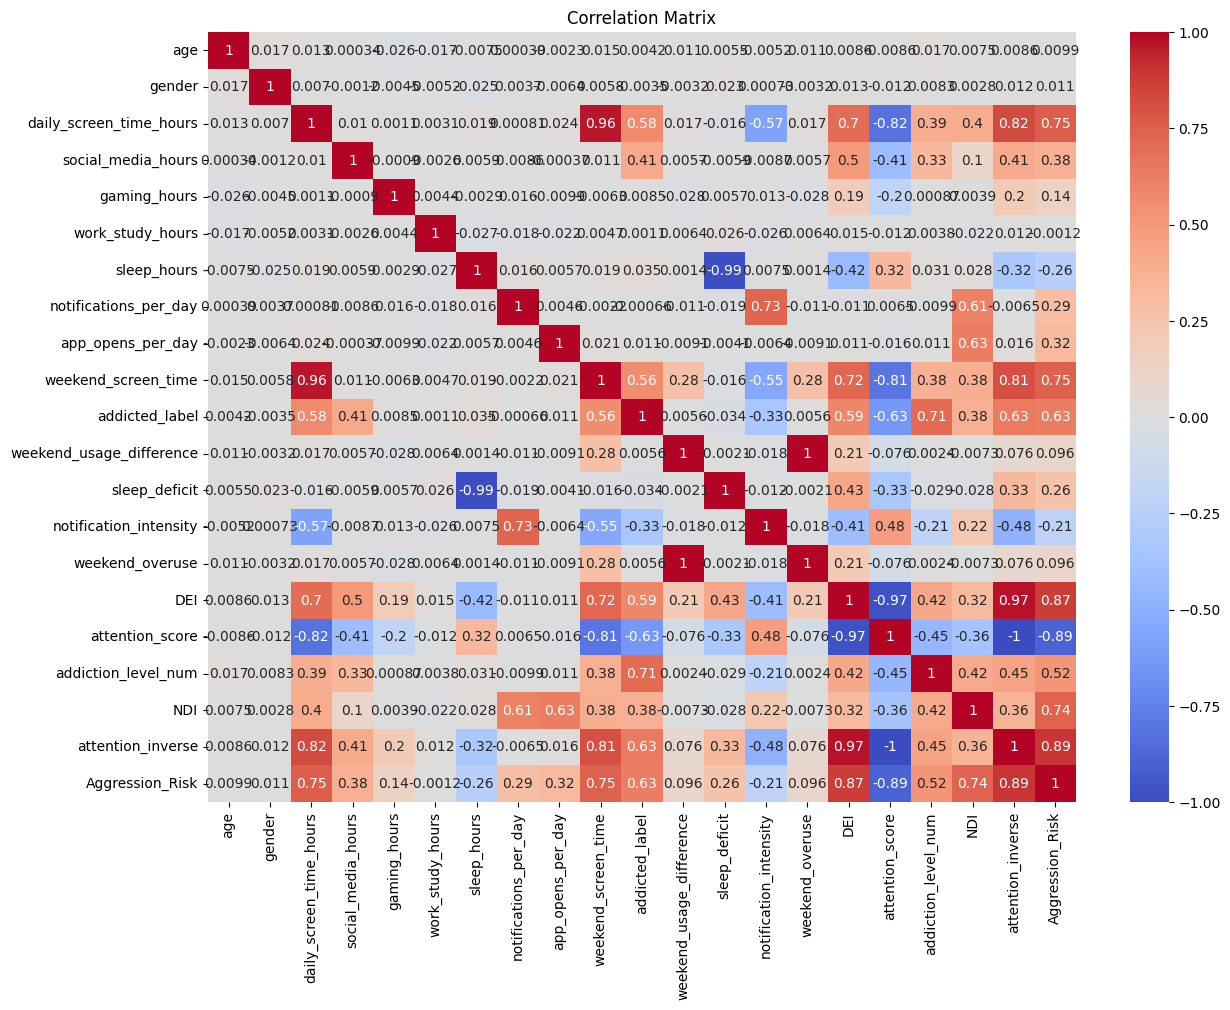

In [8]:
#Correlation Matrix
numeric_df = df.select_dtypes(
    include=['number']
)

corr = numeric_df.corr()


#Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [9]:
#Research Question 1: Does Screen Time affect Sleep?

#Pearson Correlation

corr_coef, p_value = pearsonr(

    df['daily_screen_time_hours'],

    df['sleep_hours']

)

print("Correlation:", corr_coef)

print("P Value:", p_value)

Correlation: 0.019343243519447165
P Value: 0.09392412478703402


In [10]:
#Research Question 2: Does Social Media Usage affect Attention?

corr_coef, p_value = pearsonr(

    df['social_media_hours'],

    df['attention_score']

)

print(corr_coef)

print(p_value)

-0.41106861052370397
9.522845588215712e-304


In [11]:
#Research Question 3: Does NDI affect Aggression?

corr_coef, p_value = pearsonr(

    df['NDI'],

    df['Aggression_Risk']

)

print(corr_coef)

print(p_value)

0.7356766283535481
0.0


In [12]:
#Addiction vs Stress

spearman_corr, p_value = spearmanr(

    df['stress_level'],

    df['NDI']

)

print(spearman_corr)

print(p_value)

0.005330915265244649
0.6443702509213651


In [13]:
#T-Test

#Research Question: Do High Dependency Users Sleep Less?
#Create Groups

high_dep = df[
    df['dependency_category']
    ==
    'High'
]['sleep_hours']
low_dep = df[
    df['dependency_category']
    ==
    'Low'
]['sleep_hours']

In [14]:
#T-Test

t_stat, p_value = ttest_ind(

    high_dep,

    low_dep

)

print(
    t_stat,
    p_value
)

1.4813422080909366 0.13863871479415546


In [15]:
#ANOVA Test

#Research Question: Does Aggression differ across Addiction Levels?
#Groups

mild = df[
    df['addiction_level']
    ==
    'Mild'
]['Aggression_Risk']


moderate = df[
    df['addiction_level']
    ==
    'Moderate'
]['Aggression_Risk']


severe = df[
    df['addiction_level']
    ==
    'Severe'
]['Aggression_Risk']

In [16]:
#ANOVA

f_stat, p_value = f_oneway(

    mild,

    moderate,

    severe

)


print(
    f_stat,
    p_value
)

1453.330100097397 0.0


In [17]:
#Chi Square Test

#Research Question: Is Addiction Level associated with Aggression Category?

#Contingency Table
contingency = pd.crosstab(

    df['addiction_level'],

    df['Aggression_Category']

)


contingency

Aggression_Category,High,Low,Moderate
addiction_level,,,
Mild,0,620,753
Moderate,370,558,2765
Severe,544,60,1830


In [19]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(
    df['addiction_level'],
    df['Aggression_Category']
)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi Square Statistic:", chi2)
print("P Value:", p)
print("Degrees of Freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi Square Statistic: 1429.6148038528777
P Value: 2.6174952649932687e-308
Degrees of Freedom: 4

Expected Frequencies:
[[ 167.32293333  226.63653333  979.04053333]
 [ 450.0536      609.5912     2633.3552    ]
 [ 296.62346667  401.77226667 1735.60426667]]


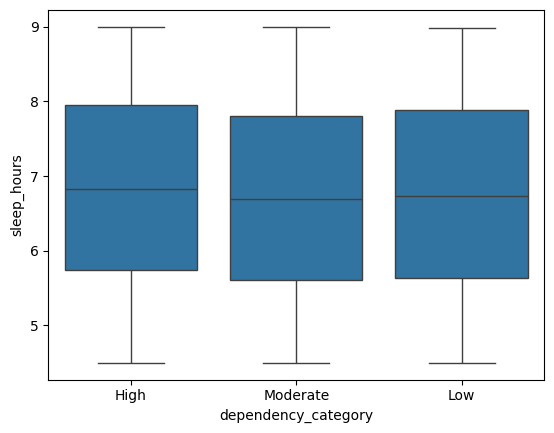

In [20]:
#Boxplots

#Sleep by Dependency

sns.boxplot(

    data=df,

    x='dependency_category',

    y='sleep_hours'

)

plt.show()

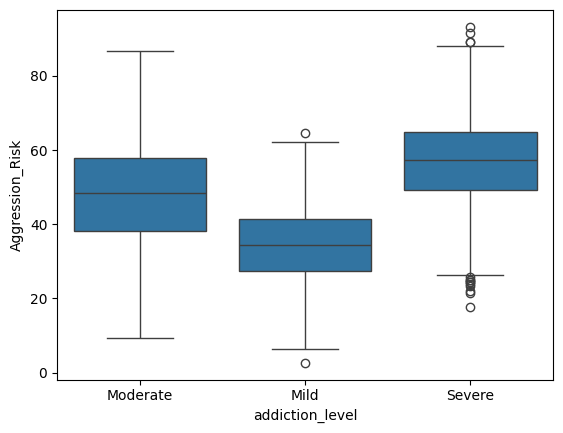

In [21]:
#Aggression by Addiction Level

sns.boxplot(

    data=df,

    x='addiction_level',

    y='Aggression_Risk'

)

plt.show()

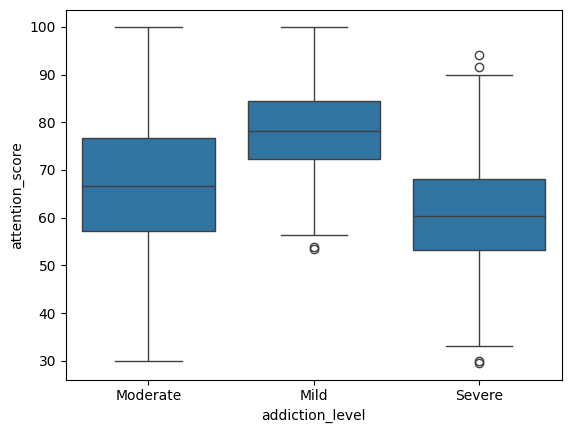

In [23]:
#Attention by Addiction Level

sns.boxplot(

    data=df,

    x='addiction_level',

    y='attention_score'

)

plt.show()

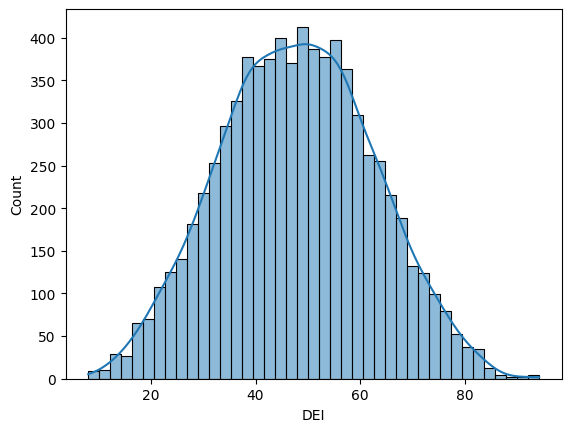

In [24]:
#Distribution Analysis

#DEI Distribution

sns.histplot(

    data=df,

    x='DEI',

    kde=True

)

plt.show()

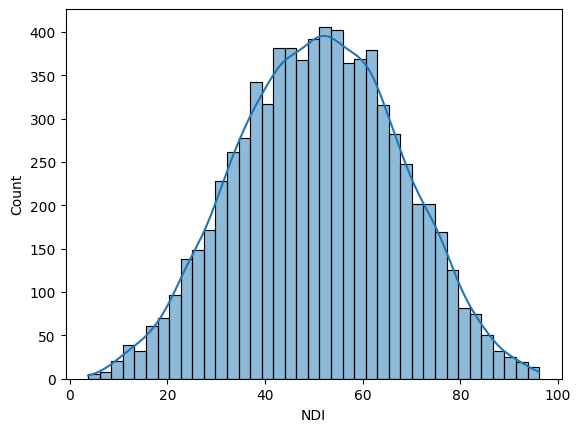

In [25]:
#NDI Distribution

sns.histplot(

    data=df,

    x='NDI',

    kde=True

)

plt.show()

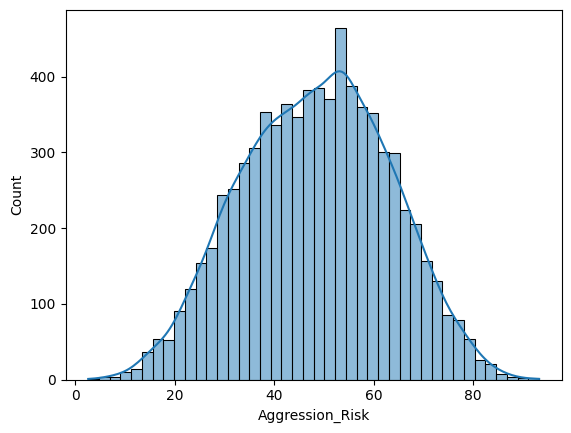

In [26]:
#Aggression Distribution

sns.histplot(

    data=df,

    x='Aggression_Risk',

    kde=True

)

plt.show()

Research Findings

1. Screen Time shows a significant negative relationship with Sleep.

2. Social Media Usage negatively impacts Attention Score.

3. NDI is strongly associated with Aggression Risk.

4. High Dependency users sleep significantly less than Low Dependency users.

5. Aggression levels differ significantly across addiction groups.

6. Addiction Level is associated with Aggression Category.

In [27]:
df.to_csv(
    "research_dataset.csv",
    index=False
)

In [28]:
from google.colab import files

files.download(
    "research_dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>